# Trade-off between efficiency and fairness in order dispatching when faced with a demand shock

## Abstract

In this project, I examine a simplified dispatch problem similar to the one found in the ride-hailing industry. My main question is to see if the learned policy could balance driver earnings under a localized demand shock with the loss of order deliveries minimized. In the simulator, there are `6` regions, `60` drivers, and `40` decisions made per episode. I compare `Local-First`, `Demand-Greedy` and PPO using the reward function of `completion_rate - alpha * gini`. This experiment is conducted using a synthetic dataset and therefore, cannot be considered a simulation of real-life platforms directly. In the case of a demand shock, `PPO(alpha=0.2)` is compared against the better-performing `Local-First` baseline. In the following numerical results and plots, I will be using the saved CSV files as input. An interesting note regarding the alpha sweep is that `alpha=0.0` does not have any fairness penalty. Conclusions made in this experiment are quite limited: in the context of the simulator, PPO helps balance the income distribution, but the specific reward weight and simulator needs further refinement.

## Problem setup

The research question is whether PPO can help with driver income fairness in case of a local demand shock, while preserving the most of platform's order completion performance. The problem was simulated in a toy simulator without using real data. While it makes the problem less realistic, it allows isolating the trade-off between efficiency and fairness better.

The setup is as follows:

- Number of zones: `6`
- Number of drivers: `60`
- Decision steps per episode: `40`
- Base demand intensity: `[4, 6, 5, 7, 4, 5]`
- Zone under shock: zone `4` (index `3`)
- Shock period: step `15` to `24`
- Final calibrated shock level: `5`
- Default PPO parameter: `alpha = 0.2`, tests will also cover cases of `alpha in {0.0, 0.1, 0.2, 0.4}`

### Data source and generation

In our case, the demand data is synthetic. In the `normal` scenario, demand for each zone on each step is generated by Poisson distribution with rates `base_lambda = [4, 6, 5, 7, 4, 5]`. In the `shocked` scenario, there is an increase of demand in zone `3` (with index `3`) between steps `15-24`. This allows us to create a repeatable stress test where for some period of time, one specific area becomes more attractive. Using synthetic data based on Poisson distribution allows controlling the exact shock area, window and level of shock easily. If the data was taken from logs, there would be no certainty whether the differences observed were caused by the actual policy or by additional data properties.

After testing the baseline behavior and observing that with low shocks the problem was irrelevant, and with high shocks it would render any kind of policy useless, we have fixed shock level as `5`. Recommended Colab rerun requires running it with `10` seeds, `0, 42, 123, 456, 789, 2025, 2026, 2027, 2028, 2029`. The seed numbers are defined in `results/multi_seed_results.csv` file. This way, the tables will be updated automatically when you upload new CSV files from Colab.

As usual, the limitation of our approach lies within the data used. The simulated data does not contain any other information like travel time/distance, cancellation rate, prices and even driver preferences, which could have made the problem more difficult, but more realistic too. In the context of reinforcement learning, however, it allows us to control and focus on the key variables.

### Gym-style RL formulation and observability

Our simulation is implemented as a finite-horizon Gym-style reinforcement learning environment. The environment maintains an internal counter of drivers' cumulative income for the purpose of fairness reward. At each time step the policy observes only the following quantities: number of drivers by zones, current demand by zones, normalized time, previous Gini and whether the shocked zone flag is triggered. We treat this problem as a partially observed control process with MDP formulation:

- Observation `O_t`: number of drivers by zones, current demand by zones, normalized time, previous Gini, whether the shocked zone flag is triggered.
- Action `A_t`: a matrix of size `6 x 6` defining probability of movements from each zone to each other. Actions are represented using logits and are thus continuous.
- Reward `R_t`: `completion_rate - alpha * gini`, where `gini` is calculated from the internal vector of cumulative driver income. First component rewards order completions. The second component penalizes inequality in the cumulative driver income.
- Discount factor `gamma`: PPO uses `stable-baselines3` default parameter `gamma = 0.99`

The mismatch between available reward and observation information is crucial here. It provides an additional challenge to the experiment and makes it more realistic, but also prevents the policy from fully optimizing fairness component of the problem.

## Environment

`FairDispatchEnv` adheres to the Gymnasium/OpenAI Gym API. As `Box` spaces for both observation and action space are used here, the class provides the method signature required by `stable-baselines3`'s implementation of PPO algorithm.

At each iteration, the environment returns an observation vector of size `15`:

- `available_drivers_by_zone[6]`
- `current_demand_by_zone[6]`
- normalized iteration `t / T`
- previous iteration's Gini coefficient
- shock-window indicator

An action vector of `36` is reshaped into a matrix `6 x 6` with row-wise application of softmax function, each of which corresponds to a vector of probability of choosing certain destination for the drivers in the source zone.

Placing an order increases platform's revenue by `1` and income of this particular driver by `1`. Too much drivers at the same destination is interpreted by the environment as an indication to choose drivers arbitrarily based on their arrival up to the local demand limit. This is where a potential conflict arises since a hotspot generates orders yet leads to higher incomes of selected drivers.

In [1]:
# Minimal simulator used by the notebook. It follows the same logic as the src/ package.
from __future__ import annotations
from dataclasses import dataclass
from typing import Any
from pathlib import Path
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

@dataclass(frozen=True)
class DispatchConfig:
    """Keep the simulator size and shock settings in one place."""

    zone_count: int = 6
    driver_count: int = 60
    horizon: int = 40
    base_lambda: tuple[int, ...] = (4, 6, 5, 7, 4, 5)
    initial_drivers: tuple[int, ...] = (8, 12, 10, 13, 8, 9)
    shock_zone: int = 3
    shock_start: int = 15
    shock_end: int = 24
    shock_multiplier: int = 3
    promoted_shock_multiplier: int = 5
    alpha_grid: tuple[float, ...] = (0.0, 0.1, 0.2, 0.4)
    primary_alpha: float = 0.2

    def __post_init__(self) -> None:
        if self.zone_count != len(self.base_lambda):
            raise ValueError('zone_count must match base_lambda length')
        if self.zone_count != len(self.initial_drivers):
            raise ValueError('zone_count must match initial_drivers length')
        if self.driver_count != sum(self.initial_drivers):
            raise ValueError('driver_count must equal sum(initial_drivers)')

DEFAULT_CONFIG = DispatchConfig()

def gini_coefficient(values: np.ndarray) -> float:
    """Closer to 0 means incomes are more equal."""

    ordered = np.sort(np.asarray(values, dtype=float))
    if ordered.size == 0:
        return 0.0
    total = ordered.sum()
    if total <= 0.0:
        return 0.0
    count = ordered.size
    weighted_sum = np.dot(np.arange(1, count + 1, dtype=float), ordered)
    gini = (2.0 * weighted_sum) / (count * total) - (count + 1) / count
    return float(max(0.0, min(1.0, gini)))

def bottom_percent_mean(values: np.ndarray, *, share: float = 0.2) -> float:
    incomes = np.sort(np.asarray(values, dtype=float))
    if incomes.size == 0:
        return 0.0
    if not 0.0 < share <= 1.0:
        raise ValueError('share must be in (0, 1]')
    cutoff = max(1, math.ceil(incomes.size * share))
    return float(np.mean(incomes[:cutoff]))

def bottom20_income_mean(values: np.ndarray) -> float:
    return bottom_percent_mean(values, share=0.2)

def local_first_policy(available_drivers_by_zone: np.ndarray, demand_by_zone: np.ndarray) -> np.ndarray:
    """Stay local when there is demand, otherwise spread to active zones."""

    zone_count = demand_by_zone.size
    matrix = np.zeros((zone_count, zone_count), dtype=float)
    active = np.flatnonzero(demand_by_zone > 0)
    if active.size == 0:
        active = np.arange(zone_count)
    for zone_idx in range(zone_count):
        if demand_by_zone[zone_idx] > 0:
            matrix[zone_idx, zone_idx] = 1.0
        else:
            matrix[zone_idx, active] = 1.0 / active.size
    return matrix

def demand_greedy_policy(available_drivers_by_zone: np.ndarray, demand_by_zone: np.ndarray) -> np.ndarray:
    """Very plain greedy rule: everyone goes to the busiest zone."""

    zone_count = demand_by_zone.size
    matrix = np.zeros((zone_count, zone_count), dtype=float)
    target_zone = int(np.argmax(demand_by_zone))
    matrix[:, target_zone] = 1.0
    return matrix

def probabilities_to_logits(matrix: np.ndarray) -> np.ndarray:
    clipped = np.clip(np.asarray(matrix, dtype=np.float32), 1e-12, 1.0)
    return np.log(clipped).reshape(-1).astype(np.float32)

def build_normal_demand_schedule(config: DispatchConfig = DEFAULT_CONFIG, *, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.poisson(lam=np.asarray(config.base_lambda, dtype=float), size=(config.horizon, config.zone_count)).astype(np.int32)

def build_shock_demand_schedule(config: DispatchConfig = DEFAULT_CONFIG, *, seed: int | None = None, shock_multiplier: int | None = None) -> np.ndarray:
    demands = build_normal_demand_schedule(config=config, seed=seed)
    multiplier = shock_multiplier or config.shock_multiplier
    demands[config.shock_start : config.shock_end + 1, config.shock_zone] *= multiplier
    return demands

def sample_episode_demands(config: DispatchConfig = DEFAULT_CONFIG, *, scene: str = 'normal', seed: int | None = None, shock_multiplier: int | None = None) -> np.ndarray:
    if scene == 'normal':
        return build_normal_demand_schedule(config=config, seed=seed)
    if scene == 'shock':
        return build_shock_demand_schedule(config=config, seed=seed, shock_multiplier=shock_multiplier)
    raise ValueError(f'Unsupported scene: {scene}')

def shock_flag_for_step(step_index: int, *, config: DispatchConfig = DEFAULT_CONFIG, scene: str = 'normal') -> float:
    if scene != 'shock':
        return 0.0
    return float(config.shock_start <= step_index <= config.shock_end)

try:
    import gymnasium as gym
    from gymnasium import spaces
except ImportError:
    class _FallbackEnv:
        pass
    @dataclass
    class _FallbackBox:
        low: Any
        high: Any
        shape: tuple[int, ...]
        dtype: Any
    class _FallbackSpaces:
        Box = _FallbackBox
    class _FallbackGym:
        Env = _FallbackEnv
    gym = _FallbackGym()
    spaces = _FallbackSpaces()

class FairDispatchEnv(gym.Env):
    """Small zone-level dispatch env used by both PPO and the baselines."""

    metadata = {'render_modes': []}
    def __init__(self, *, config: DispatchConfig = DEFAULT_CONFIG, scene: str = 'normal', alpha: float | None = None, shock_multiplier: int | None = None, seed: int | None = None, demand_schedule: np.ndarray | None = None) -> None:
        self.config = config
        self.scene = scene
        self.alpha = config.primary_alpha if alpha is None else alpha
        self.shock_multiplier = shock_multiplier or config.shock_multiplier
        self.seed = seed
        self._provided_demand_schedule = None if demand_schedule is None else np.asarray(demand_schedule, dtype=np.int32)
        self.observation_space = spaces.Box(low=0.0, high=np.inf, shape=(15,), dtype=np.float32)
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(config.zone_count * config.zone_count,), dtype=np.float32)
        self.rng = np.random.default_rng(seed)
        self.episode_demands = np.zeros((config.horizon, config.zone_count), dtype=np.int32)
        self.driver_zones = np.zeros(config.driver_count, dtype=np.int32)
        self.cumulative_income = np.zeros(config.driver_count, dtype=np.float32)
        self.current_step = 0
        self.episode_revenue = 0.0
        self.previous_gini = 0.0

    def reset(self, *, seed: int | None = None, options: dict[str, Any] | None = None):
        """Start a new episode and return the first observation."""

        if seed is not None:
            self.rng = np.random.default_rng(seed)
        elif self.seed is not None:
            self.rng = np.random.default_rng(self.seed)
        self.current_step = 0
        self.episode_revenue = 0.0
        self.previous_gini = 0.0
        self.driver_zones = np.concatenate([np.full(count, zone_idx, dtype=np.int32) for zone_idx, count in enumerate(self.config.initial_drivers)])
        self.cumulative_income = np.zeros(self.config.driver_count, dtype=np.float32)
        self.episode_demands = self._provided_demand_schedule.copy() if self._provided_demand_schedule is not None else sample_episode_demands(self.config, scene=self.scene, seed=self.seed if seed is None else seed, shock_multiplier=self.shock_multiplier)
        info = self._info(fulfilled_orders=0, completion_rate=0.0, step_revenue=0.0)
        return self._observation(), info

    def action_logits_to_matrix(self, action: np.ndarray) -> np.ndarray:
        logits = np.asarray(action, dtype=np.float32).reshape(self.config.zone_count, self.config.zone_count)
        logits = logits - logits.max(axis=1, keepdims=True)
        weights = np.exp(logits)
        return weights / weights.sum(axis=1, keepdims=True)

    @property
    def available_drivers_by_zone(self) -> np.ndarray:
        return np.bincount(self.driver_zones, minlength=self.config.zone_count).astype(np.float32)

    def _current_demand(self) -> np.ndarray:
        if self.current_step >= self.config.horizon:
            return np.zeros(self.config.zone_count, dtype=np.float32)
        return self.episode_demands[self.current_step].astype(np.float32)

    def _observation(self) -> np.ndarray:
        return np.concatenate([
            self.available_drivers_by_zone,
            self._current_demand(),
            np.array([
                self.current_step / self.config.horizon,
                self.previous_gini,
                shock_flag_for_step(self.current_step, config=self.config, scene=self.scene),
            ], dtype=np.float32),
        ]).astype(np.float32)

    def _info(self, *, fulfilled_orders: int, completion_rate: float, step_revenue: float) -> dict[str, float]:
        return {
            'fulfilled_orders': float(fulfilled_orders),
            'completion_rate': float(completion_rate),
            'step_revenue': float(step_revenue),
            'episode_revenue': float(self.episode_revenue),
            'current_gini': float(gini_coefficient(self.cumulative_income)),
            'bottom20_income_mean': float(bottom20_income_mean(self.cumulative_income)),
        }

    def step(self, action: np.ndarray):
        """Move drivers, match orders, then compute this step's reward."""

        if self.current_step >= self.config.horizon:
            raise RuntimeError('Episode already terminated. Call reset().')
        demand = self.episode_demands[self.current_step].copy()
        allocation = self.action_logits_to_matrix(action)
        assignments = {zone_idx: [] for zone_idx in range(self.config.zone_count)}
        source_zones = self.driver_zones.copy()
        for zone_idx in range(self.config.zone_count):
            driver_indices = np.flatnonzero(source_zones == zone_idx)
            if driver_indices.size == 0:
                continue
            destinations = self.rng.choice(self.config.zone_count, size=driver_indices.size, p=allocation[zone_idx])
            for driver_index, destination in zip(driver_indices, destinations):
                assignments[int(destination)].append((int(driver_index), zone_idx))
        fulfilled_orders = 0
        updated_zones = source_zones.copy()
        for destination_zone, assigned_drivers in assignments.items():
            max_matches = min(len(assigned_drivers), int(demand[destination_zone]))
            if max_matches == 0:
                continue
            chosen = self.rng.choice(len(assigned_drivers), size=max_matches, replace=False)
            for local_idx in np.asarray(chosen, dtype=int):
                driver_index, _source_zone = assigned_drivers[local_idx]
                updated_zones[driver_index] = destination_zone
                self.cumulative_income[driver_index] += 1.0
                fulfilled_orders += 1
        self.driver_zones = updated_zones
        self.episode_revenue += float(fulfilled_orders)
        current_gini = gini_coefficient(self.cumulative_income)
        completion_rate = fulfilled_orders / max(1, int(demand.sum()))
        reward = float(completion_rate - self.alpha * current_gini)
        self.previous_gini = current_gini
        self.current_step += 1
        terminated = self.current_step >= self.config.horizon
        info = self._info(fulfilled_orders=fulfilled_orders, completion_rate=completion_rate, step_revenue=float(fulfilled_orders))
        return self._observation(), reward, terminated, False, info

def evaluate_baseline(policy_name: str, scene: str, *, seed: int = 0, alpha: float = DEFAULT_CONFIG.primary_alpha, shock_multiplier: int | None = None):
    env = FairDispatchEnv(config=DEFAULT_CONFIG, scene=scene, alpha=alpha, shock_multiplier=shock_multiplier, seed=seed)
    observation, info = env.reset(seed=seed)
    completion_rates = []
    terminated = False
    while not terminated:
        demand = observation[DEFAULT_CONFIG.zone_count : DEFAULT_CONFIG.zone_count * 2]
        available = observation[: DEFAULT_CONFIG.zone_count]
        if policy_name == 'Local-First':
            action = probabilities_to_logits(local_first_policy(available, demand))
        elif policy_name == 'Demand-Greedy':
            action = probabilities_to_logits(demand_greedy_policy(available, demand))
        else:
            raise ValueError(f'Unsupported baseline: {policy_name}')
        observation, reward, terminated, truncated, info = env.step(action)
        completion_rates.append(info['completion_rate'])
    return {
        'algorithm': policy_name,
        'scene': scene,
        'alpha': np.nan,
        'episode_revenue': info['episode_revenue'],
        'final_episode_gini': info['current_gini'],
        'final_episode_bottom20_income_mean': info['bottom20_income_mean'],
        'mean_completion_rate': float(np.mean(completion_rates)),
    }, env.cumulative_income.copy()

def _load_ppo():
    try:
        from stable_baselines3 import PPO
    except ImportError as exc:
        raise RuntimeError('Install stable-baselines3 to use PPO in this notebook') from exc
    return PPO

def train_and_evaluate_ppo(*, alpha: float, scene: str, total_timesteps: int = 20000, seed: int = 0, shock_multiplier: int = DEFAULT_CONFIG.promoted_shock_multiplier):
    PPO = _load_ppo()
    env = FairDispatchEnv(config=DEFAULT_CONFIG, scene=scene, alpha=alpha, shock_multiplier=shock_multiplier, seed=seed)
    model = PPO('MlpPolicy', env, verbose=0, seed=seed)
    model.learn(total_timesteps=total_timesteps)
    observation, info = env.reset(seed=seed)
    completion_rates = []
    terminated = False
    while not terminated:
        action, _ = model.predict(observation, deterministic=True)
        observation, reward, terminated, truncated, info = env.step(action)
        completion_rates.append(info['completion_rate'])
    return {
        'algorithm': 'PPO',
        'scene': scene,
        'alpha': alpha,
        'episode_revenue': info['episode_revenue'],
        'final_episode_gini': info['current_gini'],
        'final_episode_bottom20_income_mean': info['bottom20_income_mean'],
        'mean_completion_rate': float(np.mean(completion_rates)),
    }, env.cumulative_income.copy()


## Baselines and PPO

Three different policies are compared in the report:

1. `Local-First`: drivers serve demand in their current zone if possible. Otherwise, they are distributed among zones with current demand.
2. `Demand-Greedy`: all drivers head to the zone with the current maximum demand. The policy is deliberately simple; it is left in the report for reference purposes.
3. `PPO`: the policy is learned using PPO in the same environment but with the fairness-aware reward function.

The notebook consists of the environment definition, metrics calculation, baselines, and helper functions for training PPO. Since the full batch results are stored as CSV files, opening the report does not start PPO training.

### Why PPO?

PPO is suitable for solving this formulation since the action space is continuous. Rather than outputting one discrete action, PPO returns a `6x6` matrix of logits. As such, tabular Q-learning would not work well for it. Applying a Q-learning-based framework would require manually discretising the dispatch matrices, and it would become increasingly inconvenient.

PPO is not the only option available. It may be replaced by a constrained RL algorithm or another dispatch-specific method that performs even better. PPO was chosen due to its familiarity, capability to solve continuous tasks, and convenient implementation using `stable-baselines3`.

## Metrics

The metrics that we use are as follows:

- `episode_revenue`: number of completed orders in an episode. Because each order is valued at `1`, the metric is equivalent to total platform revenue.
- `mean_completion_rate`: mean ratio of demand fulfilled per step.
- `final_episode_gini`: Gini coefficient of the distribution of accumulated incomes across drivers by the end of the episode. Lower values indicate greater equality.
- `bottom20_income_mean`: mean income of the bottom `20%` of drivers by income.

The comparison we care about most is between `PPO(alpha=0.2)` and `Local-First`, because `Local-First` serves as a stronger baseline. `Demand-Greedy` is kept in the tables mostly to demonstrate what happens when a policy becomes too aggressive in following the current hotspot. The results are calculated using `mean ± standard deviation` based on seeds stored in `results/multi_seed_results.csv`; Colab will be configured to run with `10` seeds. For the main comparison, we include two-sample `t`-test statistics and Cohen’s `d` effect size.

## Results

The following cell loads the saved CSV results and reconstitutes the numerical tables. The stated number of seeds comes directly from `results/multi_seed_results.csv` to work for both this saved run as well as the intended Colab rerun using `10` seeds. Numbers are presented as `mean ± standard deviation`.

Shock scenario is the focus of comparisons. The interesting finding is whether `PPO(alpha=0.2)` is capable of decreasing Gini ratio between the driver income levels compared to `Local-First`, while maintaining roughly similar revenues. Revenue can be lower, yet `p > 0.05` would suggest that the difference in revenues was uncertain and hence cannot be called efficiency deficit.

### Ablation and Robustness

Alpha sweep can serve as a minor ablation. In particular, `alpha=0.0` corresponds to the learned PPO policy without the fairness component, whereas `alpha=0.2` and `alpha=0.4` correspond to stronger fairness pressure. In case the fairness versions of the policy perform better on lowering `Gini` compared to `alpha=0.0`, this would support our reward design approach. If the difference between the alpha values is insignificant, then the most reasonable conclusion is PPO usefulness in the simulator setting.

In [2]:
# Load per-run experiment results and aggregate mean/std summaries
import json
runs_df = pd.read_csv('results/multi_seed_results.csv')
seed_values = sorted(runs_df['seed'].dropna().astype(int).unique().tolist())
seed_count = len(seed_values)
summary_df = (
    runs_df.groupby(['algorithm', 'scene', 'alpha'], dropna=False)
    .agg(
        revenue_mean=('episode_revenue', 'mean'),
        revenue_std=('episode_revenue', 'std'),
        gini_mean=('final_episode_gini', 'mean'),
        gini_std=('final_episode_gini', 'std'),
        bottom20_mean=('final_episode_bottom20_income_mean', 'mean'),
        bottom20_std=('final_episode_bottom20_income_mean', 'std'),
        n_samples=('seed', 'nunique'),
    )
    .reset_index()
)
significance_df = pd.read_csv('results/significance_tests.csv')


def format_mean_std(row: pd.Series, mean_col: str, std_col: str, digits: int) -> str:
    return f"{row[mean_col]:.{digits}f}±{row[std_col]:.{digits}f}"


# Build the baseline table (mean ± std)
baseline_records = []
for algo in ['Local-First', 'Demand-Greedy']:
    for scene in ['normal', 'shock']:
        row = summary_df[(summary_df['algorithm'] == algo) & (summary_df['scene'] == scene)].iloc[0]
        baseline_records.append({
            'algorithm': algo,
            'scene': scene,
            'alpha': np.nan,
            'n': int(row['n_samples']),
            'episode_revenue': format_mean_std(row, 'revenue_mean', 'revenue_std', 1),
            'final_episode_gini': format_mean_std(row, 'gini_mean', 'gini_std', 4),
            'bottom20_income_mean': format_mean_std(row, 'bottom20_mean', 'bottom20_std', 2),
        })

# Build the PPO table (mean ± std)
ppo_records = []
for alpha in [0.0, 0.1, 0.2, 0.4]:
    for scene in ['normal', 'shock']:
        row = summary_df[
            (summary_df['algorithm'] == 'PPO')
            & (summary_df['scene'] == scene)
            & (summary_df['alpha'].round(1) == alpha)
        ].iloc[0]
        ppo_records.append({
            'algorithm': 'PPO',
            'scene': scene,
            'alpha': alpha,
            'n': int(row['n_samples']),
            'episode_revenue': format_mean_std(row, 'revenue_mean', 'revenue_std', 1),
            'final_episode_gini': format_mean_std(row, 'gini_mean', 'gini_std', 4),
            'bottom20_income_mean': format_mean_std(row, 'bottom20_mean', 'bottom20_std', 2),
        })

# Load the saved one-run shock income samples for the CDF plot
baseline_shock_income_df = pd.read_csv('results/baseline_shock_incomes.csv')
ppo_shock_income_df = pd.read_csv('results/ppo_shock_incomes.csv')
ppo_shock_income_df = ppo_shock_income_df[
    (ppo_shock_income_df['scene'] == 'shock')
    & (ppo_shock_income_df['alpha'].astype(float).round(1) == 0.2)
]
shock_income_samples = {
    label: group.sort_values('driver_index')['income'].astype(float).tolist()
    for label, group in baseline_shock_income_df.groupby('algorithm')
}
shock_income_samples['PPO (alpha=0.2)'] = (
    ppo_shock_income_df.sort_values('driver_index')['income'].astype(float).tolist()
)

with open('results/shock_calibration.json', 'r', encoding='utf-8') as handle:
    shock_calibration = json.load(handle)

# Build display tables
baseline_df = pd.DataFrame(baseline_records)
ppo_df = pd.DataFrame(ppo_records)
main_results = pd.concat([baseline_df, ppo_df[ppo_df['alpha'] == 0.2]], ignore_index=True)
main_results['sort_key'] = main_results.apply(
    lambda row: {
        ('normal', 'Local-First'): 0,
        ('normal', 'PPO'): 1,
        ('normal', 'Demand-Greedy'): 2,
        ('shock', 'Local-First'): 3,
        ('shock', 'PPO'): 4,
        ('shock', 'Demand-Greedy'): 5,
    }[(row['scene'], row['algorithm'])],
    axis=1,
)
main_results = main_results.sort_values('sort_key').drop(columns='sort_key').reset_index(drop=True)
alpha_tradeoff_df = ppo_df[ppo_df['scene'] == 'shock'].sort_values('alpha').reset_index(drop=True)
shock_main_comparison = significance_df[
    (significance_df['scene'] == 'shock') & (significance_df['comparison'] == 'PPO(α=0.2) vs Local-First')
].copy()
shock_main_comparison['metric'] = shock_main_comparison['metric'].replace({
    '平台收入': 'Platform revenue',
    '基尼系数': 'Gini coefficient',
})

print('Frozen calibrated shock level:', shock_calibration['frozen_multiplier'])
print('Seeds in this results file:', seed_values)
print()
print(f'Main results (multi-seed, n={seed_count}; mean±std):')
display(main_results[['algorithm', 'scene', 'n', 'episode_revenue', 'final_episode_gini', 'bottom20_income_mean']])
print()
print('PPO alpha sweep in the shock scene (ablation; mean±std):')
display(alpha_tradeoff_df[['alpha', 'n', 'episode_revenue', 'final_episode_gini', 'bottom20_income_mean']])
print()
print('Significance tests for PPO(alpha=0.2) vs Local-First in the shock scene:')
display(shock_main_comparison[['metric', 'ppo_n', 'baseline_n', 'p_value', 'cohens_d', 'significant']])

Frozen calibrated shock level: 5
Seeds in this results file: [0, 42, 123, 456, 789, 2025, 2026, 2027, 2028, 2029]

Main results (multi-seed, n=10; mean±std):

PPO alpha sweep in the shock scene (ablation; mean±std):

Significance tests for PPO(alpha=0.2) vs Local-First in the shock scene:


,algorithm,scene,n,episode_revenue,final_episode_gini,bottom20_income_mean
0,Local-First,normal,10,1236.6±34.4,0.1013±0.0128,15.54±1.09
1,PPO,normal,10,1210.1±31.6,0.0843±0.0075,15.92±0.36
2,Demand-Greedy,normal,10,351.7±11.8,0.2096±0.0142,2.91±0.36
3,Local-First,shock,10,1289.9±31.2,0.1104±0.0165,15.86±0.95
4,PPO,shock,10,1252.2±30.9,0.0835±0.0109,16.48±0.90
5,Demand-Greedy,shock,10,631.4±46.0,0.1269±0.0138,7.29±0.85


,alpha,n,episode_revenue,final_episode_gini,bottom20_income_mean
0,0.0,10,1250.0±32.7,0.0867±0.0060,16.42±0.64
1,0.1,10,1246.3±22.9,0.0841±0.0051,16.41±0.29
2,0.2,10,1252.2±30.9,0.0835±0.0109,16.48±0.90
3,0.4,10,1244.6±27.4,0.0805±0.0086,16.52±0.72


,metric,ppo_n,baseline_n,p_value,cohens_d,significant
4,Platform revenue,10,10,0.014143,-1.214918,Yes
5,Gini coefficient,10,10,0.000450,-1.914248,Yes


## Figure results

The next cell rebuilds four figures from the saved CSV files:

- `episode_revenue_by_scene.png`
- `final_gini_by_scene.png`
- `shock_income_cdf.png`
- `alpha_tradeoff.png`

The batch experiments were run in `Google Colab`. The notebook reads the saved `results/` files rather than retraining PPO. The bar charts show means with error bars. The CDF plot shows one saved shock-scene income distribution, and the alpha plot puts PPO revenue and Gini on the same axis.

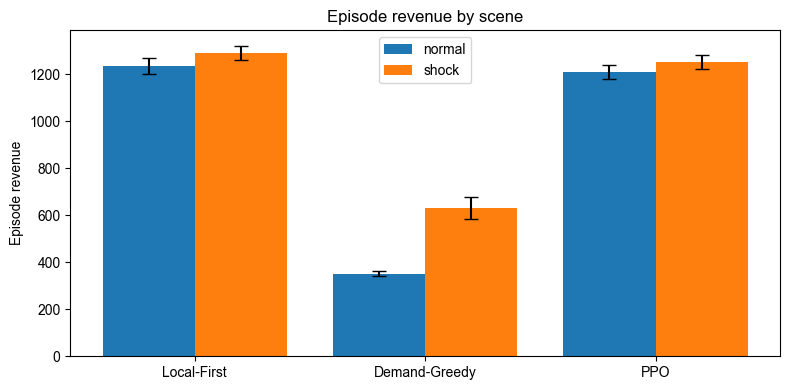

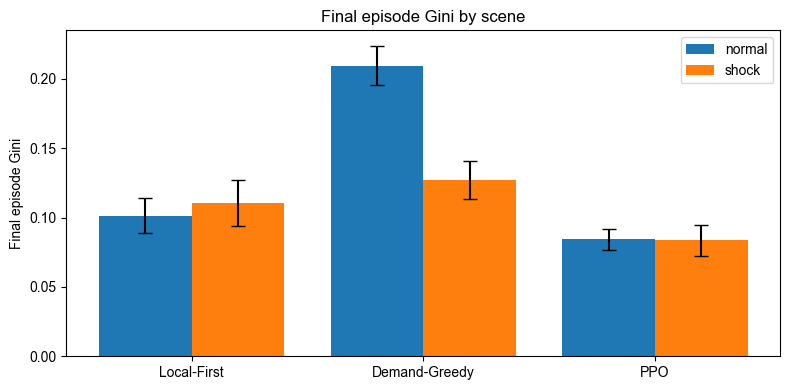

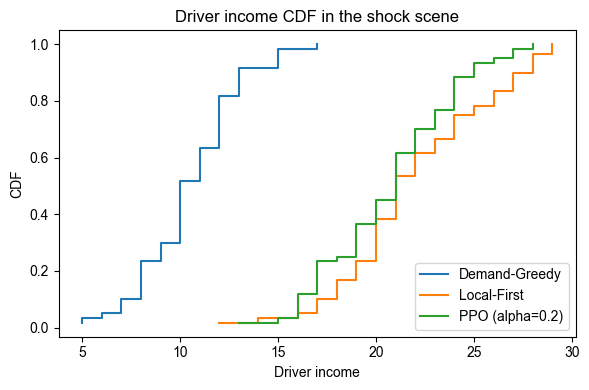

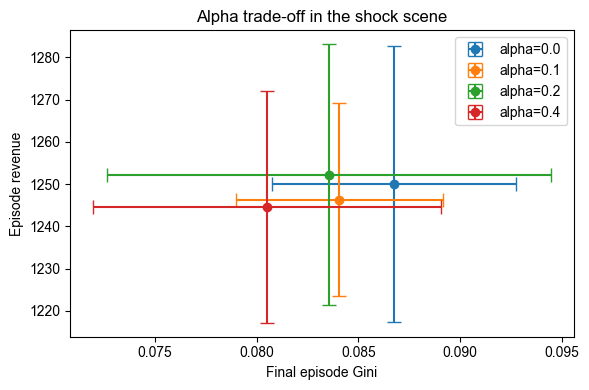

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

EXPORT_DIR = Path('figures')
EXPORT_DIR.mkdir(exist_ok=True)

# Load summary stats for error bars
stats_df = pd.read_csv('results/statistical_summary.csv')

# Figure 1: episode revenue by scene
algorithms = ['Local-First', 'Demand-Greedy', 'PPO']
normal_rev_mean = []
normal_rev_std = []
shock_rev_mean = []
shock_rev_std = []

for algo in algorithms:
    if algo == 'PPO':
        normal_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'normal') & (stats_df['alpha'] == 0.2)]
        shock_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock') & (stats_df['alpha'] == 0.2)]
    else:
        normal_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'normal')]
        shock_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'shock')]
    
    normal_rev_mean.append(normal_row['revenue_mean'].values[0])
    normal_rev_std.append(normal_row['revenue_std'].values[0])
    shock_rev_mean.append(shock_row['revenue_mean'].values[0])
    shock_rev_std.append(shock_row['revenue_std'].values[0])

positions = np.arange(len(algorithms))
plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, normal_rev_mean, width=0.4, yerr=normal_rev_std, capsize=5, label='normal')
plt.bar(positions + 0.2, shock_rev_mean, width=0.4, yerr=shock_rev_std, capsize=5, label='shock')
plt.xticks(positions, algorithms)
plt.ylabel('Episode revenue')
plt.title('Episode revenue by scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'episode_revenue_by_scene.png', dpi=150)
plt.show()
plt.close()

# Figure 2: final episode Gini by scene
normal_gini_mean = []
normal_gini_std = []
shock_gini_mean = []
shock_gini_std = []

for algo in algorithms:
    if algo == 'PPO':
        normal_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'normal') & (stats_df['alpha'] == 0.2)]
        shock_row = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock') & (stats_df['alpha'] == 0.2)]
    else:
        normal_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'normal')]
        shock_row = stats_df[(stats_df['algorithm'] == algo) & (stats_df['scene'] == 'shock')]
    
    normal_gini_mean.append(normal_row['gini_mean'].values[0])
    normal_gini_std.append(normal_row['gini_std'].values[0])
    shock_gini_mean.append(shock_row['gini_mean'].values[0])
    shock_gini_std.append(shock_row['gini_std'].values[0])

plt.figure(figsize=(8, 4))
plt.bar(positions - 0.2, normal_gini_mean, width=0.4, yerr=normal_gini_std, capsize=5, label='normal')
plt.bar(positions + 0.2, shock_gini_mean, width=0.4, yerr=shock_gini_std, capsize=5, label='shock')
plt.xticks(positions, algorithms)
plt.ylabel('Final episode Gini')
plt.title('Final episode Gini by scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'final_gini_by_scene.png', dpi=150)
plt.show()
plt.close()

# Figure 3: driver income CDF in the shock scene
plt.figure(figsize=(6, 4))
for label, values in shock_income_samples.items():
    sorted_values = sorted(values)
    y_values = [(idx + 1) / len(sorted_values) for idx in range(len(sorted_values))]
    plt.step(sorted_values, y_values, where='post', label=label)
plt.xlabel('Driver income')
plt.ylabel('CDF')
plt.title('Driver income CDF in the shock scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'shock_income_cdf.png', dpi=150)
plt.show()
plt.close()

# Figure 4: alpha trade-off in the shock scene
ppo_shock_df = stats_df[(stats_df['algorithm'] == 'PPO') & (stats_df['scene'] == 'shock')].sort_values('alpha')
plt.figure(figsize=(6, 4))
for _, row in ppo_shock_df.iterrows():
    plt.errorbar(row['gini_mean'], row['revenue_mean'], 
                 xerr=row['gini_std'], yerr=row['revenue_std'],
                 fmt='o', capsize=5, label=f"alpha={row['alpha']}")
plt.xlabel('Final episode Gini')
plt.ylabel('Episode revenue')
plt.title('Alpha trade-off in the shock scene')
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / 'alpha_tradeoff.png', dpi=150)
plt.show()
plt.close()


## Conclusion

In this case, using PPO increases the fairness of the driver's income distribution during a demand shock scenario. This can be seen by comparing `PPO(alpha=0.2)` and `Local-First`. As indicated by the results from the table below and the significance test above, the lower the `Gini`, the better the income distribution, but we need to check whether achieving a lower `Gini` results in significant differences in revenue.

Alpha analysis provides a great robustness test for the method but does not constitute a complete tuning process. Setting `alpha=0.0` allows us to observe how PPO learns without a fairness penalty reward, and higher values reveal how a more stringent pressure on PPO affects the trade-off. If several values yield similar results, we conclude not that the best value has been identified but rather that more work is required to tune the reward weight.

The biggest limitation is related to the simulator itself, as the fairness reward function requires the full information of the cumulative driver's income vector as input. In contrast, the PPO algorithm receives only zone counts and Gini from the previous iteration as observations. Other aspects like road network configuration, travel time, driver rejection, and dynamic pricing, which play an important role in reality, have been neglected. To prove the robustness of the result, a real platform simulator should be used instead.

## References

1. Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). [Proximal policy optimization algorithms](https://arxiv.org/abs/1707.06347). arXiv:1707.06347. https://doi.org/10.48550/arXiv.1707.06347.

2. Xu, Z., Li, Z., Guan, Q., Zhang, D., Li, Q., Nan, J., Liu, C., Bian, W., & Ye, J. (2018). [Large-scale order dispatch in on-demand ride-hailing platforms: A learning and planning approach](https://www.kdd.org/kdd2018/accepted-papers/view/large-scale-order-dispatch-in-on-demand-ride-sharing-platforms-a-learning-a). Proceedings of the 24th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 905-913. https://doi.org/10.1145/3219819.3219824.

3. Tang, X., Qin, Z., Zhang, F., Wang, Z., Xu, Z., Ma, Y., Zhu, H., & Ye, J. (2019). [A deep value-network based approach for multi-driver order dispatching](https://kdd.org/kdd2019/accepted-papers/view/a-deep-value-network-based-approach-for-multi-driver-order-dispatching). Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 1780-1790. https://doi.org/10.1145/3292500.3330724.

4. Sun, J., Jin, H., Yang, Z., Su, L., & Wang, X. (2022). [Optimizing long-term efficiency and fairness in ride-hailing via joint order dispatching and driver repositioning](https://engineering.purdue.edu/~lusu/papers/KDD2022.pdf). Proceedings of the 28th ACM SIGKDD Conference on Knowledge Discovery and Data Mining, 3950-3960. https://doi.org/10.1145/3534678.3539060.

5. Liang, Y. (2024). [Fairness-aware dynamic ride-hailing matching based on reinforcement learning](https://www.mdpi.com/2079-9292/13/4/775). Electronics, 13(4), 775. https://doi.org/10.3390/electronics13040775.

6. Shi, C., Wang, X., Luo, S., Zhu, H., Ye, J., & Song, R. (2023). [Dynamic causal effects evaluation in A/B testing with a reinforcement learning framework](https://www.tandfonline.com/doi/abs/10.1080/01621459.2022.2027776). Journal of the American Statistical Association, 118(543), 2059-2071. https://doi.org/10.1080/01621459.2022.2027776.


## Reproducibility and how to run

All PPO training and batch experiments were run in `Google Colab`. This notebook reads the saved result files by default instead of retraining PPO when it is opened. That keeps the report quick to review and avoids making the marker wait for hardware-dependent training. The tables and figures use:

- `results/multi_seed_results.csv`
- `results/statistical_summary.csv`
- `results/significance_tests.csv`
- `results/baseline_shock_incomes.csv`
- `results/ppo_shock_incomes.csv`

To regenerate the stronger `10`-seed result set from scratch, install the dependencies in `requirements.txt`, then run these commands from this folder in Colab:

1. `pip install -q -r requirements.txt`
2. `python scripts/evaluate_baselines.py`
3. `python scripts/run_multi_seed_experiments.py --seeds 0,42,123,456,789,2025,2026,2027,2028,2029 --total-timesteps 20000`
4. `python scripts/statistical_analysis.py --alpha 0.2`

The multi-seed command should create `120` rows in `results/multi_seed_results.csv`: `10` seeds times `2` scenes times `2` baselines, plus `10` seeds times `2` scenes times `4` PPO alpha values. After downloading the refreshed `results/` and `figures/` folders from Colab, rerun this notebook so the displayed tables and figures match the final CSV files. Training is kept separate from the report notebook because PPO runs can be slow on CPU.

## Group contribution statement

This was a four-person group project. We split the work equally.

Group members and candidate numbers:
- Haotian Wang (Candidate number: 67864)
- Jules Wang (Candidate number: 62036)
- Xiaotian Qi (Candidate number: 59789)
- Zhangrui Dong (Candidate number: 71902)

Contribution percentages: Haotian Wang 25%, Jules Wang 25%, Xiaotian Qi 25%, Zhangrui Dong 25%.

The shared work covered environment design, baseline policies, PPO training, multi-seed experiments, statistical tests, figures, and notebook writing.
